# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
import zipfile
import xml.etree.ElementTree as ET

## 2. Data importation

In [2]:
def read_sales_sheet(zip_path, sheet_xml):
    with zipfile.ZipFile(zip_path) as z:
        with z.open('xl/sharedStrings.xml') as f:
            ss_root = ET.parse(f).getroot()
        ns = {'ns': 'http://purl.oclc.org/ooxml/spreadsheetml/main'}
        strings = []
        for si in ss_root.findall('.//ns:si', ns):
            texts = [t.text for t in si.findall('.//ns:t', ns) if t.text]
            strings.append(''.join(texts))

        with z.open(sheet_xml) as f:
            sheet_root = ET.parse(f).getroot()
        rows = []
        for row in sheet_root.findall('.//ns:row', ns):
            row_data = []
            for cell in row.findall('ns:c', ns):
                v = cell.find('ns:v', ns)
                t = cell.get('t')
                if v is not None:
                    row_data.append(strings[int(v.text)] if t == 's' else v.text)
                else:
                    row_data.append(None)
            rows.append(row_data)

    max_len = max(len(r) for r in rows)
    rows = [r + [None] * (max_len - len(r)) for r in rows]
    return pd.DataFrame(rows[1:], columns=rows[0])

In [3]:
SALES_PATH  = 'Case2_data_extract_share.xlsx'
MARKET_PATH = 'Case2_market_data_share.xlsx'
train_data = read_sales_sheet(SALES_PATH, 'xl/worksheets/sheet1.xml')
test_data = read_sales_sheet(SALES_PATH, 'xl/worksheets/sheet3.xml')

In [4]:
df_market = pd.read_excel(MARKET_PATH, sheet_name='Sheet1')
df_period_map = pd.read_excel(MARKET_PATH, sheet_name='Sheet2')
#df_period_map['Period'] = df_period_map['Period'].astype(int)

## 3. Data exploration and understanding

### 3.1. Data Overview

In [5]:
#overview the dataset
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Anon Period              4237 non-null   object
 1   TGL Biz Desc             4237 non-null   object
 2   TGL Business Unit        4237 non-null   object
 3   TGL Business Segment     4237 non-null   object
 4   TGL Business Subsegment  4237 non-null   object
 5   Orders cons. (anon)      4237 non-null   object
 6   Revenue cons. (anon)     4237 non-null   object
dtypes: object(7)
memory usage: 231.8+ KB


- At first sight, the training dataset has no missing values and have 4237 rows. 
- The datatypes, are not correct so we will have to fix them. 

In [6]:
#changing the name of the variables do it is easy to track them
train_data = train_data.rename(columns={
    'Anon Period': 'Period',
    'TGL Biz Desc': 'Biz_Desc',
    'TGL Business Unit': 'Business_Unit',
    'TGL Business Segment': 'Segment',
    'TGL Business Subsegment': 'Subsegment',
    'Orders cons. (anon)': 'Orders',
    'Revenue cons. (anon)': 'Revenue'
})

In [7]:
#changing the datatypes so it is possible to visualize the data
train_data['Period'] = train_data['Period'].round().astype('Int32')
train_data['Orders'] = train_data['Orders'].round().astype('Int32')
train_data['Revenue'] = train_data['Revenue'].round().astype('Int32')

In [8]:
#overview the dataset
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Period         4237 non-null   Int32 
 1   Biz_Desc       4237 non-null   object
 2   Business_Unit  4237 non-null   object
 3   Segment        4237 non-null   object
 4   Subsegment     4237 non-null   object
 5   Orders         4237 non-null   Int32 
 6   Revenue        4237 non-null   Int32 
dtypes: Int32(3), object(4)
memory usage: 194.6+ KB


In [9]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 78 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    180 non-null    int64  
 1   China_Core_Inflation_Rate                 178 non-null    float64
 2   China_Exports                             178 non-null    float64
 3   China_GDP                                 15 non-null     float64
 4   China_GDP_from_Construction               60 non-null     float64
 5   China_GDP_from_Manufacturing              60 non-null     float64
 6   China_Industrial_Production               176 non-null    float64
 7   China_Industrial_Production_Mom           170 non-null    float64
 8   China_Inflation_Rate                      178 non-null    float64
 9   China_Interest_Rate                       137 non-null    float64
 10  China_Steel_Production                

- Considering that the total number of rows is 180 (corresponding to the number of years), most of the columns have a considerable amount of missing values.

In [10]:
#first 20 rows
train_data.head(20)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277
1,2,SSI,SSI027,SSI02710,SSI02710,0,334
2,3,SSI,SSI027,SSI02710,SSI02710,0,334
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468
6,7,SSI,SSI027,SSI02710,SSI02710,0,334
7,8,SSI,SSI027,SSI02710,SSI02710,0,334
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094


In [11]:
#first 20 rows
df_market.head(20)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6955.00
1,-130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7264.00
2,-129,1.0,137.35,NaN,10710.5,76425.9,13.70,NaN,2.9,NaN,...,0.9,153.326,NaN,554.4,1925.9,8.5,0.2,1.1,NaN,7090.00
3,-128,1.1,145.45,NaN,NaN,NaN,13.40,NaN,3.3,NaN,...,0.9,156.763,NaN,NaN,NaN,7.7,0.4,1.2,0.25,6764.00
4,-127,1.1,139.26,NaN,NaN,NaN,13.90,NaN,3.5,NaN,...,0.9,157.769,NaN,NaN,NaN,6.9,0.4,1.1,0.25,6619.00
5,-126,1.1,144.99,NaN,18012.5,118221.6,13.30,NaN,3.6,NaN,...,0.8,158.624,NaN,549.2,1947.4,6.3,0.3,1.1,0.25,6605.00
6,-125,1.3,135.96,NaN,NaN,NaN,13.10,NaN,4.4,NaN,...,0.6,164.234,NaN,NaN,NaN,5.7,-0.3,1.2,0.25,6543.00
7,-124,1.5,153.29,NaN,NaN,NaN,13.30,NaN,5.1,NaN,...,0.8,165.621,NaN,NaN,NaN,5.4,0.1,1.1,0.25,6418.00
8,-123,1.7,154.14,6192.56,27259.3,165123.1,13.50,NaN,4.6,NaN,...,0.8,168.510,15048.97,545.1,1957.6,6.1,1.0,1.5,0.25,6648.00
9,-122,2.3,150.70,NaN,NaN,NaN,13.41,NaN,4.9,NaN,...,1.0,169.897,NaN,NaN,NaN,4.7,-0.2,1.6,0.25,7191.38


In [12]:
#descriptive statistics for numerical data
train_data.describe()

,Period,Orders,Revenue
count,4237.0,4237.0,4237.0
mean,22.510031,40076623.578475,35976412.567855
std,12.238664,70414862.658063,63786043.938389
min,1.0,-56101878.0,-12010755.0
25%,12.0,871389.0,1020192.0
50%,23.0,9281978.0,8850535.0
75%,33.0,43312847.0,36460128.0
max,42.0,595094385.0,420036087.0


- The dataset has 42 months.
- There are rows in *Orders* and *Revenue* that are negative- Is it possible?

In [13]:
#descriptive statistics for numerical data
df_market.describe().round(2)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
count,180.00,178.00,178.00,15.00,60.00,60.00,176.00,170.00,178.00,137.00,...,178.00,178.00,15.00,60.00,60.00,178.00,178.00,178.00,175.00,180.00
mean,-41.50,1.37,215.89,13031.13,33122.37,173068.40,7.42,0.65,2.08,4.21,...,2.59,209.07,20549.85,719.75,2129.46,1.03,0.07,2.60,1.43,6908.79
std,52.11,0.60,56.05,4130.32,22602.81,96035.07,5.04,3.29,1.49,0.69,...,1.40,31.90,4404.15,143.70,148.43,3.86,1.33,1.98,1.75,529.05
min,-131.00,-0.30,80.38,6192.56,4749.00,42670.30,-13.50,-22.10,-0.80,3.10,...,0.60,147.14,15048.97,533.20,1906.30,-17.20,-13.20,-0.20,0.25,4746.00
25%,-86.25,0.90,177.79,10208.83,13793.25,93960.05,5.40,0.44,1.30,3.70,...,1.70,188.11,17244.41,572.33,2000.15,-0.98,-0.28,1.42,0.25,6648.25
50%,-41.50,1.50,204.65,12537.56,28693.25,163199.35,6.30,0.55,2.00,4.30,...,2.10,198.92,19612.10,654.10,2104.35,1.60,0.10,2.10,0.25,6955.50
75%,3.25,1.80,263.34,16599.06,47756.28,227774.98,9.05,0.76,2.70,4.31,...,3.18,215.55,22610.57,867.68,2251.68,3.18,0.50,3.08,2.00,7270.16
max,48.00,2.50,339.66,18743.80,88862.80,404518.50,35.10,36.56,6.50,5.77,...,6.60,283.27,29184.89,904.40,2389.00,16.10,6.60,9.10,5.50,7960.90


- Unlike *train_data*, the period goes form -131 to 48. 

### 3.2. Checking Duplicates

In [14]:
#checking number of duplicates
train_data.duplicated().sum()

np.int64(0)

In [15]:
#checking number of duplicates
df_market.duplicated().sum()

np.int64(0)

- None of the datasets present duplicates.

### 3.3. Checking Missing Values

In [16]:
#checking number of missing values
train_data.isna().sum()

Period           0
Biz_Desc         0
Business_Unit    0
Segment          0
Subsegment       0
Orders           0
Revenue          0
dtype: int64

- The train dataset does not present any missing values which is a good sign.

In [17]:
#checking number of missing values
df_market.isna().sum()

Period                                       0
China_Core_Inflation_Rate                    2
China_Exports                                2
China_GDP                                  165
China_GDP_from_Construction                120
                                          ... 
United_States_Industrial_Production          2
United_States_Industrial_Production_Mom      2
United_States_Inflation_Rate                 2
United_States_Interest_Rate                  5
United_States_Steel_Production               0
Length: 78, dtype: int64

In [18]:
pd.set_option('display.max_rows', None)
df_market.isna().sum()/len(df_market) * 100

Period                                       0.000000
China_Core_Inflation_Rate                    1.111111
China_Exports                                1.111111
China_GDP                                   91.666667
China_GDP_from_Construction                 66.666667
China_GDP_from_Manufacturing                66.666667
China_Industrial_Production                  2.222222
China_Industrial_Production_Mom              5.555556
China_Inflation_Rate                         1.111111
China_Interest_Rate                         23.888889
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   1.111111
France_Exports                               1.111111
France_GDP                                  91.666667
France_GDP_from_Construction                66.666667
France_GDP_from_Manufacturing               66.666667
France_Industrial_Production                 1.111111
France_Industrial_Production_Mom             1.111111
France_Inflation_Rate       

- Some columns present a high amount of missing values- almost 92% of the total data. In those cases, the information given is not sufficiently significant to consider these variables.


In [19]:
#creating a variable that has df_market data from the 1 to 42 months 
df_market_months = df_market[df_market['Period'].between(1, 42)]

In [20]:
pd.set_option('display.max_rows', None)
df_market_months.isna().sum()/len(df_market_months) * 100

Period                                        0.000000
China_Core_Inflation_Rate                     0.000000
China_Exports                                 0.000000
China_GDP                                    92.857143
China_GDP_from_Construction                  66.666667
China_GDP_from_Manufacturing                 66.666667
China_Industrial_Production                   2.380952
China_Industrial_Production_Mom               0.000000
China_Inflation_Rate                          0.000000
China_Interest_Rate                           0.000000
China_Steel_Production                        0.000000
France_Core_Inflation_Rate                    0.000000
France_Exports                                0.000000
France_GDP                                   92.857143
France_GDP_from_Construction                 66.666667
France_GDP_from_Manufacturing                66.666667
France_Industrial_Production                  0.000000
France_Industrial_Production_Mom              0.000000
France_Inf

- If we consider only the observations whose period we are going to consider when merging with *train_data*, some of these observations have 100% missing values. In those cases, it is useless to consider them. 
- All variables that have missing values, also have a high percentage (>60%), except for *United_States_Interest_Rate* that has only 2.3% and *China_Industrial_Production* that has 2.3%. Therefore, these are the only variables worth of handling missing values.

In [38]:
#removing the columns considered irrelevant
drop=['China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'China_GDP', 
      'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 
      'France_Steel_Production', 'Germany_GDP', 
      'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 
      'Italy_GDP', 'Italy_GDP_from_Construction',
      'Italy_GDP_from_Manufacturing', 'Italy_Steel_Production', 
      'Japan_GDP', 'Japan_GDP_from_Construction', 'Japan_GDP_from_Manufacturing', 
      'Switzerland_GDP', 'Switzerland_Industrial_Production', 'Switzerland_Industrial_Production_Mom',
      'United_Kingdom_GDP', 'United_Kingdom_GDP_from_Construction', 'United_Kingdom_GDP_from_Manufacturing', 
      'United_Kingdom_Steel_Production', 'United_States_GDP', 'United_States_GDP_from_Construction',
      'United_States_GDP_from_Manufacturing' ]
df_market= df_market.drop(columns=drop, errors='ignore')

### 3.4. Checking Outliers

In [39]:
#setting metric fearures for train_data
metric_features_train= ['Revenue', 'Orders']

In [40]:
#setting metric fearures for df_market
metric_features_market= ['China_Core_Inflation_Rate', 'China_Exports', #'China_GDP', 
                         'China_Industrial_Production', 'China_Industrial_Production_Mom', 
                         'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 
                         'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production',
                         'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 
                         'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_Industrial_Production', 
                         'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 
                         'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_Industrial_Production',
                         'Italy_Industrial_Production_Mom', 'Italy_Inflation_Rate', 'Italy_Interest_Rate', 'Japan_Core_Inflation_Rate',
                         'Japan_Exports', 'Japan_Industrial_Production', 'Japan_Industrial_Production_Mom', 'Japan_Inflation_Rate', 
                         'Japan_Interest_Rate', 'Japan_Steel_Production', 'Switzerland_Core_Inflation_Rate', 'Switzerland_Exports', 
                         'Switzerland_Inflation_Rate', 'Switzerland_Interest_Rate', 'United_Kingdom_Core_Inflation_Rate', 'United_Kingdom_Exports', 
                         'United_Kingdom_Industrial_Production', 'United_Kingdom_Industrial_Production_Mom', 'United_Kingdom_Inflation_Rate', 
                         'United_Kingdom_Interest_Rate', 'United_States_Core_Inflation_Rate', 'United_States_Exports', 
                         'United_States_Industrial_Production', 'United_States_Industrial_Production_Mom', 'United_States_Inflation_Rate', 
                         'United_States_Steel_Production'
]

In [41]:
def plot_multiple_boxplots(data, feats, n_cols=2, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

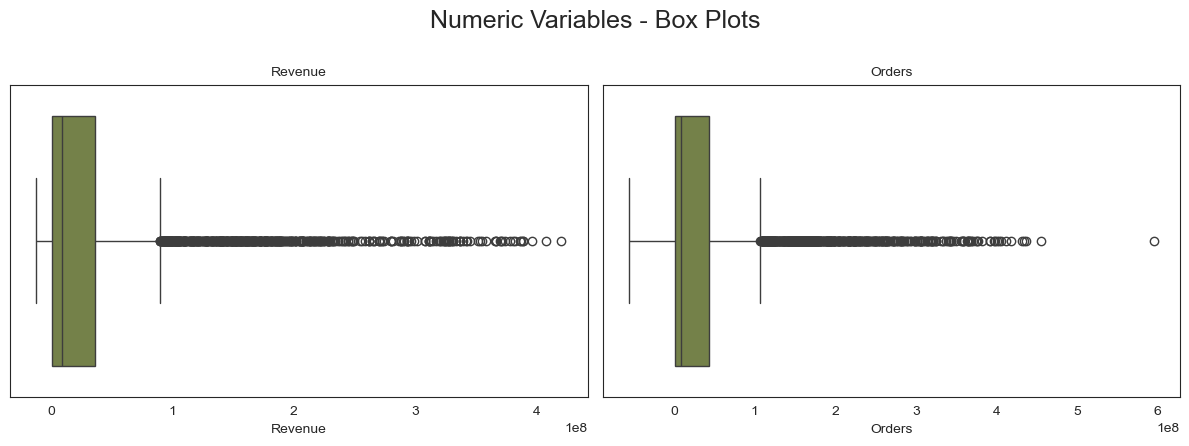

In [43]:
#applying the function to our numerical features
plot_multiple_boxplots(train_data, metric_features_train)

In [26]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

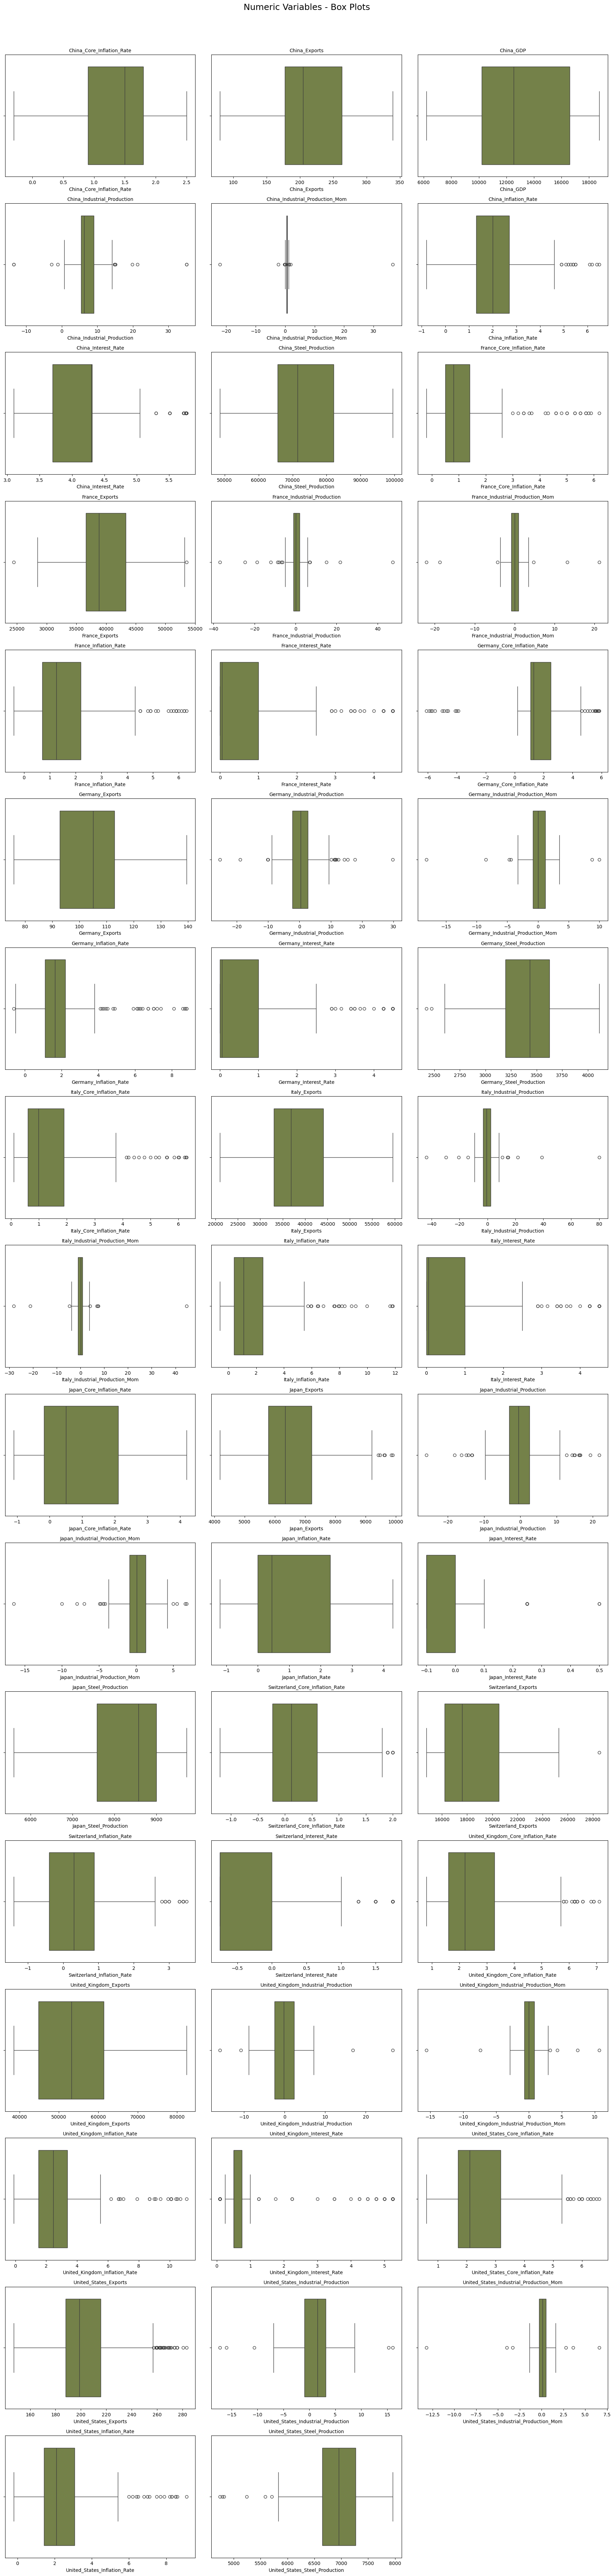

In [27]:
#applying the function to our numerical features
plot_multiple_boxplots(df_market, metric_features_market)

### 3.5. Checking Distribution

In [44]:
df= pd.DataFrame(train_data[metric_features_train])

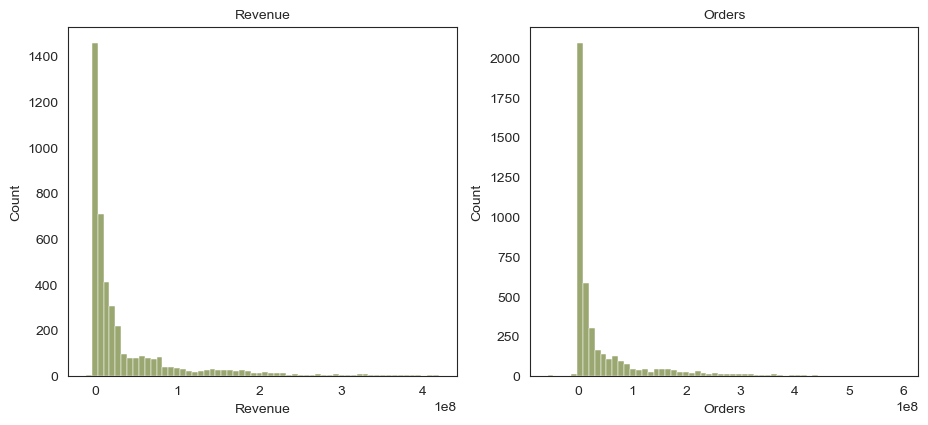

In [45]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = train_data.sample(n=min(N, len(train_data)), random_state=42)

#selecting numeric variables
cols = metric_features_train

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

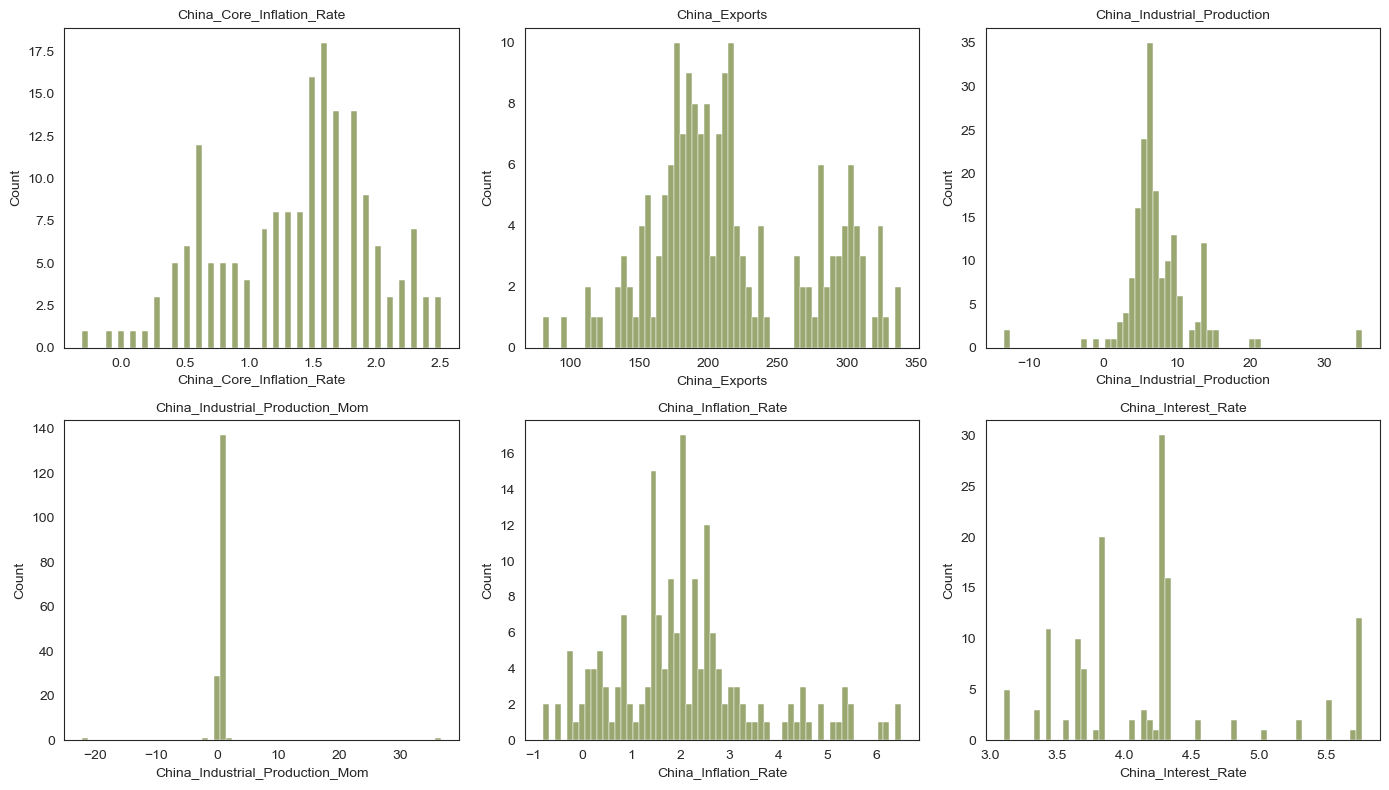

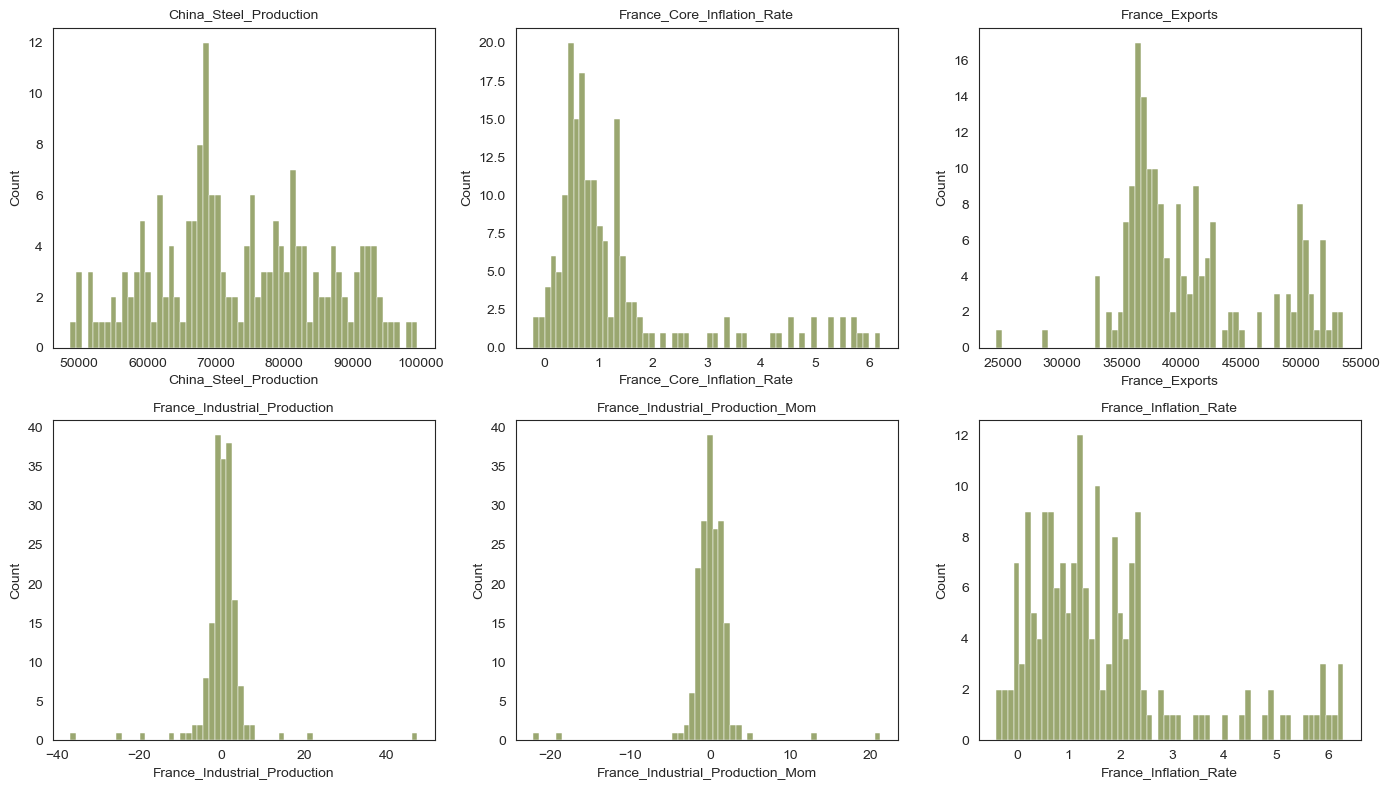

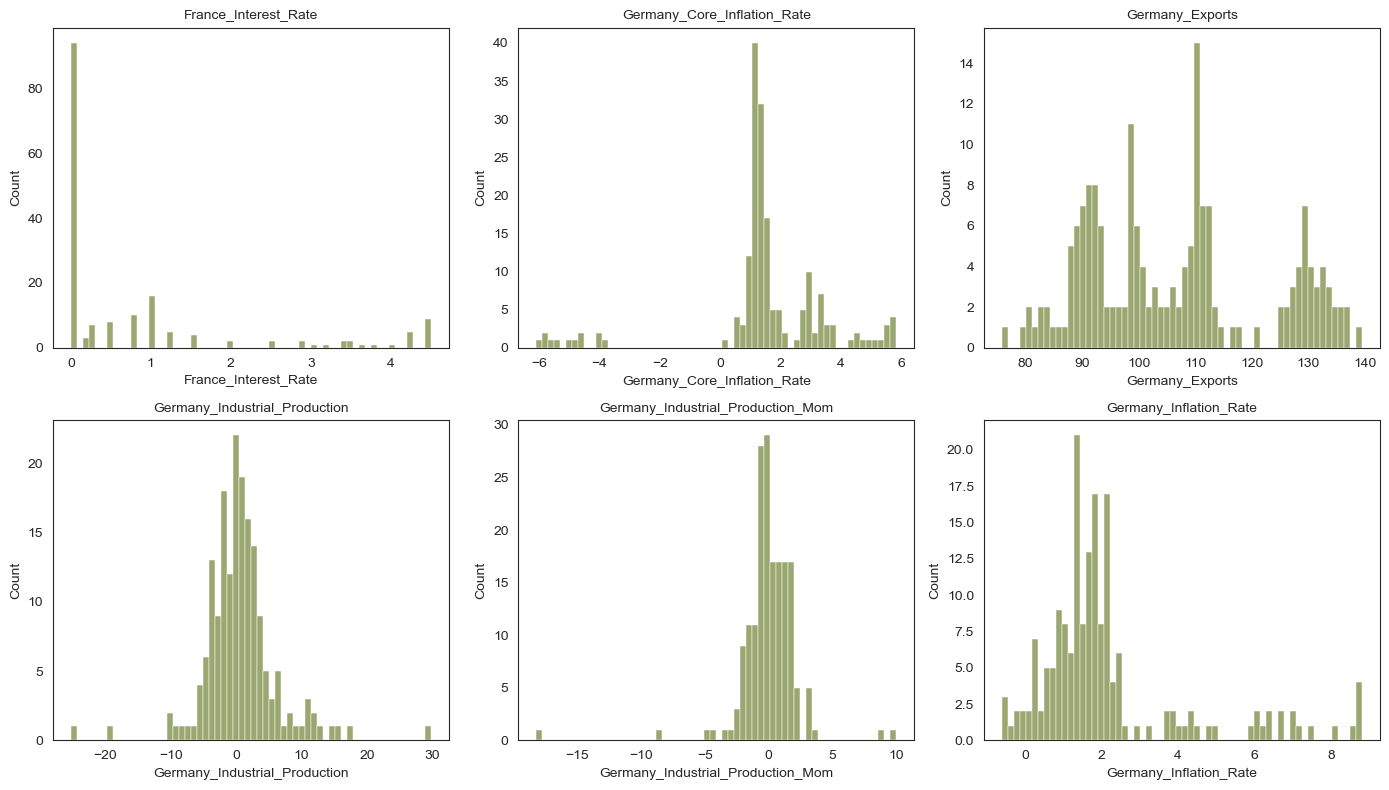

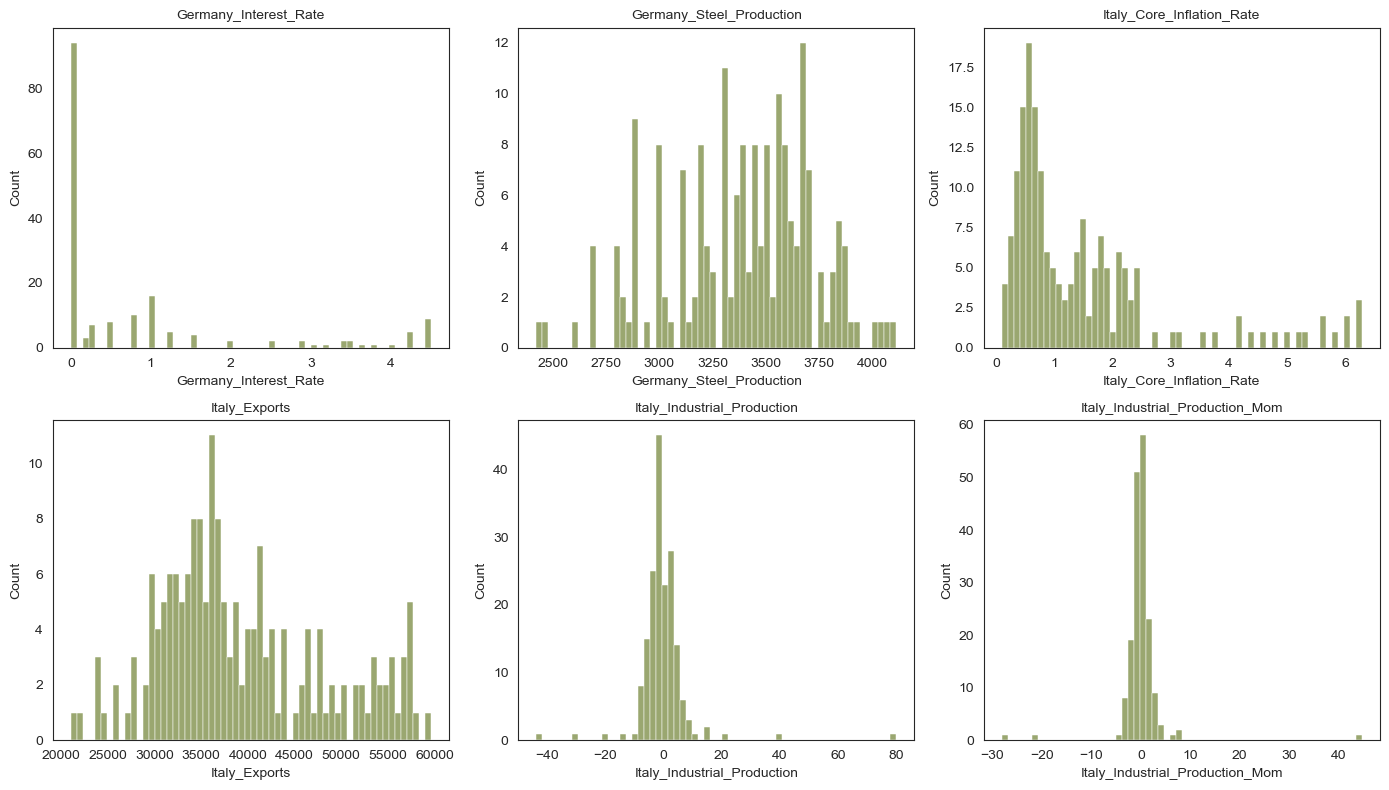

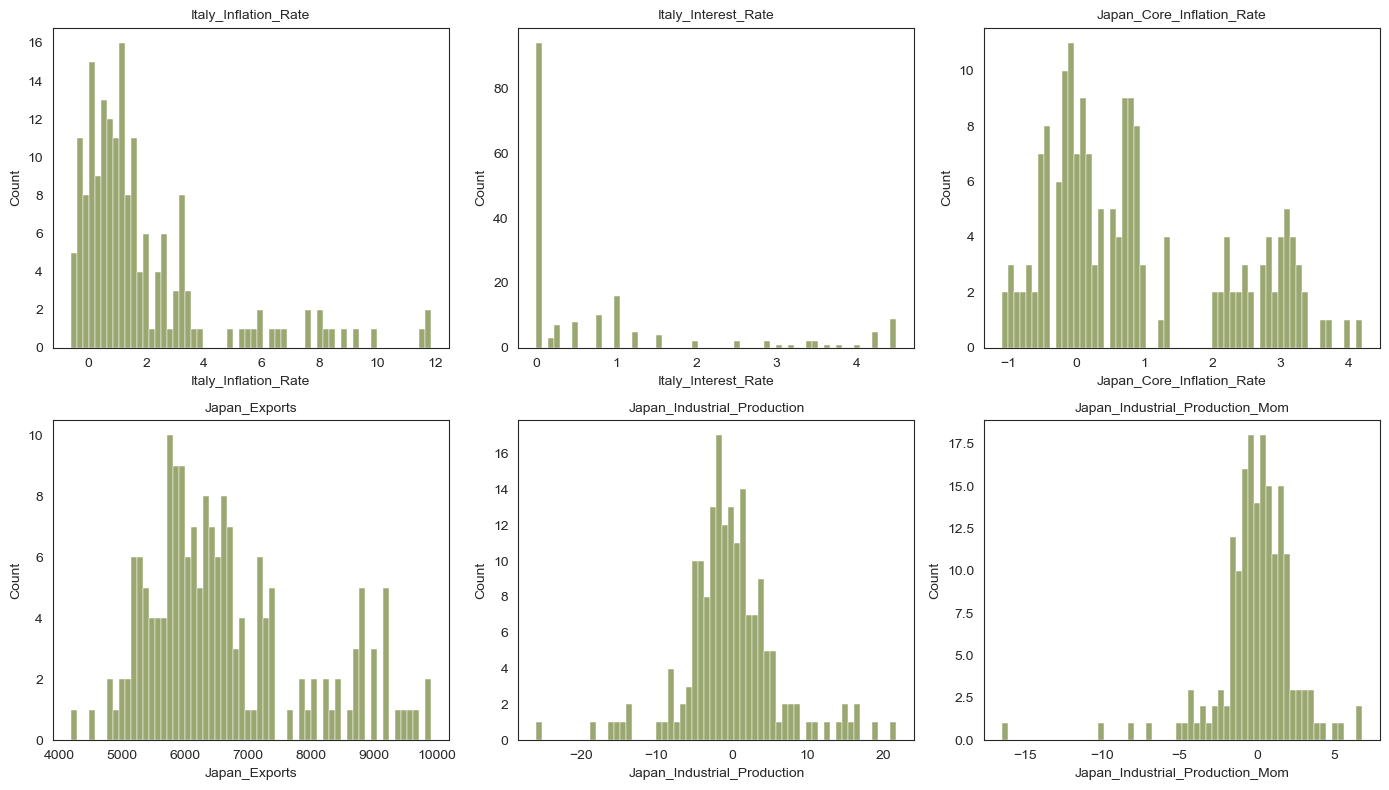

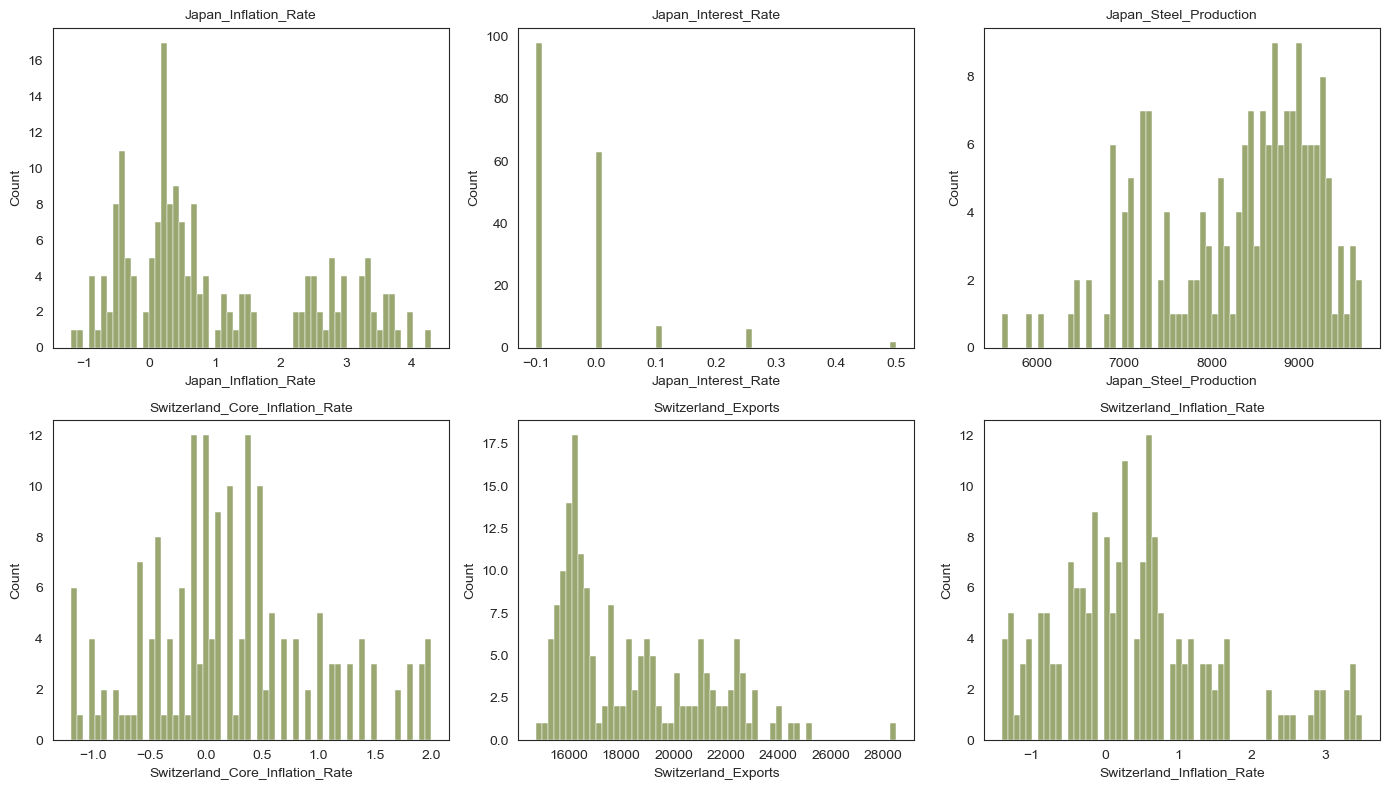

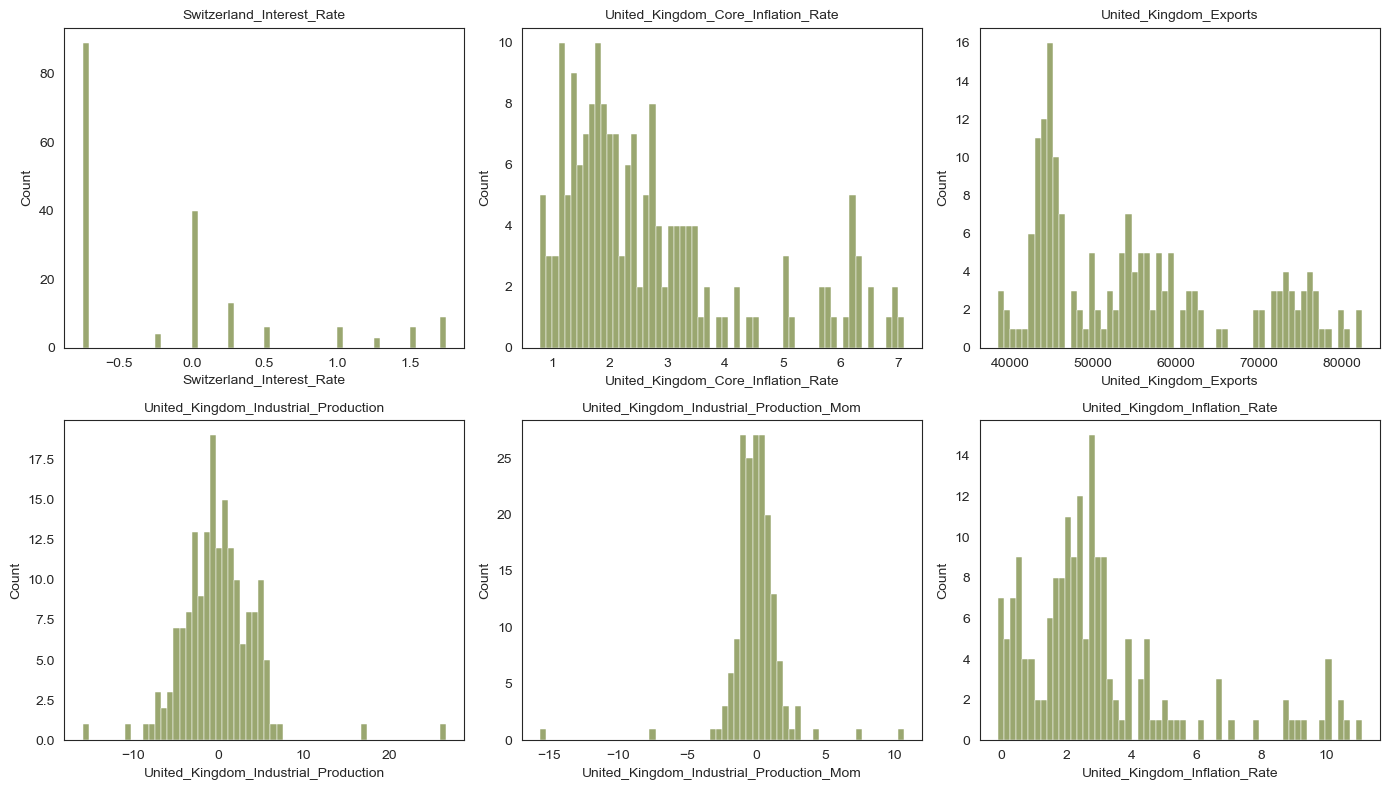

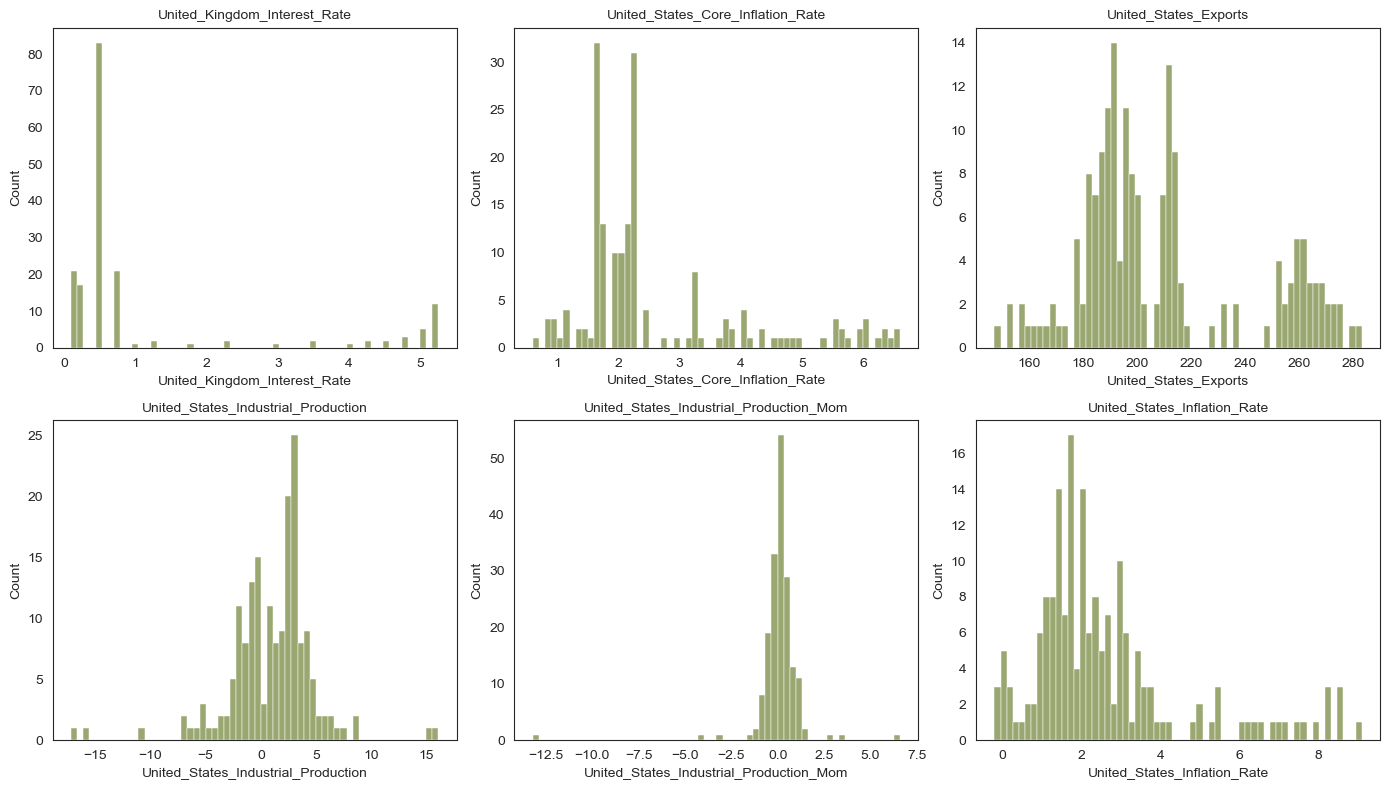

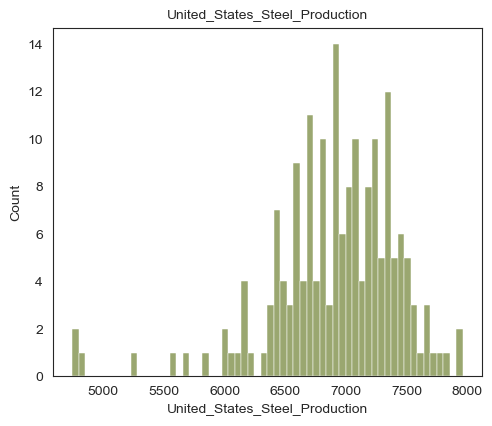

In [46]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = df_market.sample(n=min(N, len(df_market)), random_state=42)

#selecting numeric variables
cols = metric_features_market

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

### 3.6. Checking Correlation between variables

In [47]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = df_market[metric_features_market].corr(method ='spearman')
cor_spearman

,China_Core_Inflation_Rate,China_Exports,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,China_Steel_Production,France_Core_Inflation_Rate,France_Exports,France_Industrial_Production,...,United_Kingdom_Industrial_Production,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Inflation_Rate,United_Kingdom_Interest_Rate,United_States_Core_Inflation_Rate,United_States_Exports,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Steel_Production
China_Core_Inflation_Rate,1.000000,-0.601535,0.350778,0.110067,0.489509,0.763456,-0.519185,-0.470539,-0.445736,0.285797,...,0.129136,0.063294,-0.045124,-0.278393,-0.419716,-0.410172,0.244042,0.004236,-0.203296,0.346979
China_Exports,-0.601535,1.000000,-0.534005,-0.253287,-0.556201,-0.716840,0.765034,0.413557,0.755412,-0.136397,...,-0.067462,-0.037299,0.165909,0.332794,0.594231,0.779905,-0.144228,-0.012998,0.491679,-0.088536
China_Industrial_Production,0.350778,-0.534005,1.000000,0.483968,0.298135,0.475174,-0.574685,-0.303811,-0.630758,0.148160,...,0.088079,-0.068754,0.003491,-0.349172,-0.597015,-0.527057,0.388441,0.171938,-0.232295,0.212601
China_Industrial_Production_Mom,0.110067,-0.253287,0.483968,1.000000,0.304943,0.031023,-0.199254,-0.143508,-0.453833,-0.143587,...,-0.057605,-0.015859,-0.015704,-0.163640,-0.408471,-0.410135,-0.062856,0.074491,-0.183883,-0.031805
China_Inflation_Rate,0.489509,-0.556201,0.298135,0.304943,1.000000,0.473119,-0.457820,-0.131786,-0.592795,0.044202,...,-0.106269,0.034190,0.105715,-0.117586,-0.334955,-0.541774,0.289531,0.082164,-0.142046,0.358545
China_Interest_Rate,0.763456,-0.716840,0.475174,0.031023,0.473119,1.000000,-0.594454,-0.732886,-0.712972,0.077431,...,0.504204,0.089586,-0.518614,-0.386924,-0.649751,-0.619018,0.170641,-0.071090,-0.632366,0.397936
China_Steel_Production,-0.519185,0.765034,-0.574685,-0.199254,-0.457820,-0.594454,1.000000,0.242274,0.664963,-0.144723,...,0.081263,0.012418,-0.018187,0.186418,0.454955,0.655751,-0.306479,0.051236,0.344398,-0.123561
France_Core_Inflation_Rate,-0.470539,0.413557,-0.303811,-0.143508,-0.131786,-0.732886,0.242274,1.000000,0.558090,0.022037,...,-0.434278,-0.130584,0.638881,0.565150,0.710207,0.464588,0.095544,-0.001930,0.687309,-0.015814
France_Exports,-0.445736,0.755412,-0.630758,-0.453833,-0.592795,-0.712972,0.664963,0.558090,1.000000,0.067335,...,-0.053031,-0.020413,0.274422,0.566934,0.774614,0.892917,-0.164116,-0.113626,0.580744,-0.117215
France_Industrial_Production,0.285797,-0.136397,0.148160,-0.143587,0.044202,0.077431,-0.144723,0.022037,0.067335,1.000000,...,-0.039428,-0.026367,0.239327,0.043892,-0.086632,-0.008043,0.293918,-0.063027,0.119369,-0.037797


In [48]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

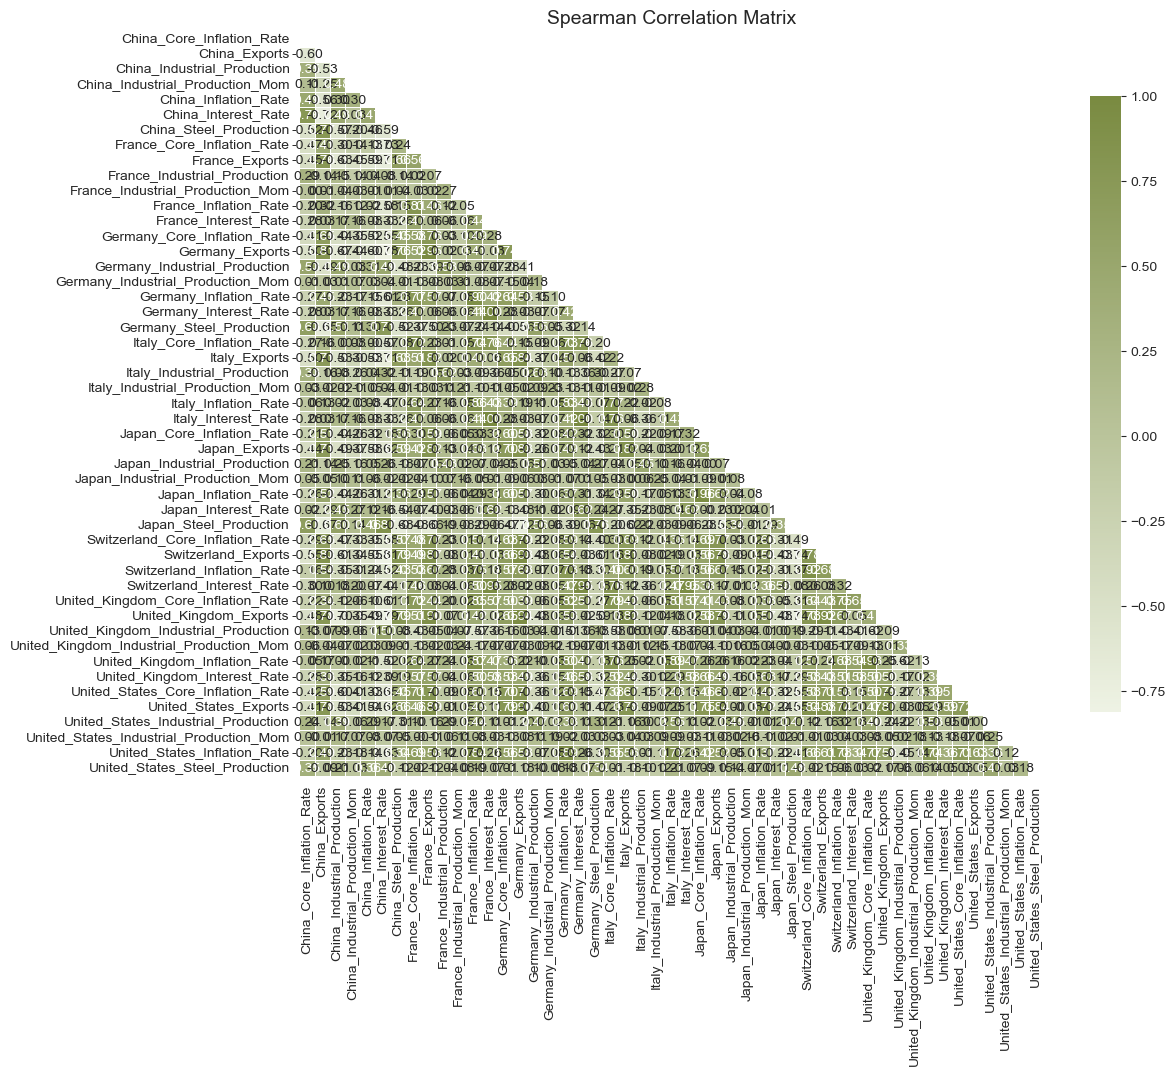

In [49]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

In [50]:
df_merged = train_data.merge(df_market, on='Period', how='left')

print(df_merged.shape)
print(df_merged.head())

(4237, 57)
   Period Biz_Desc Business_Unit   Segment Subsegment  Orders  Revenue  \
0       1      SSI        SSI027  SSI02710   SSI02710       0  -390277   
1       2      SSI        SSI027  SSI02710   SSI02710       0      334   
2       3      SSI        SSI027  SSI02710   SSI02710       0      334   
3       4      SSI        SSI027  SSI02710   SSI02710       0  1811758   
4       5      SSI        SSI027  SSI02710   SSI02710       0    80112   

   China_Core_Inflation_Rate  China_Exports  China_Industrial_Production  ...  \
0                        0.7         263.09                          9.8  ...   
1                        0.9         263.23                          8.8  ...   
2                        0.9         280.30                          8.3  ...   
3                        1.3         281.28                          6.4  ...   
4                        1.2         293.17                          5.3  ...   

   United_Kingdom_Industrial_Production_Mom  United_Kingd

In [51]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 57 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    4237 non-null   Int32  
 1   Biz_Desc                                  4237 non-null   object 
 2   Business_Unit                             4237 non-null   object 
 3   Segment                                   4237 non-null   object 
 4   Subsegment                                4237 non-null   object 
 5   Orders                                    4237 non-null   Int32  
 6   Revenue                                   4237 non-null   Int32  
 7   China_Core_Inflation_Rate                 4237 non-null   float64
 8   China_Exports                             4237 non-null   float64
 9   China_Industrial_Production               4131 non-null   float64
 10  China_Industrial_Production_Mom     

In [52]:
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Period                                      0.000000
Biz_Desc                                    0.000000
Business_Unit                               0.000000
Segment                                     0.000000
Subsegment                                  0.000000
Orders                                      0.000000
Revenue                                     0.000000
China_Core_Inflation_Rate                   0.000000
China_Exports                               0.000000
China_Industrial_Production                 2.501770
China_Industrial_Production_Mom             0.000000
China_Inflation_Rate                        0.000000
China_Interest_Rate                         0.000000
China_Steel_Production                      0.000000
France_Core_Inflation_Rate                  0.000000
France_Exports                              0.000000
France_Industrial_Production                0.000000
France_Industrial_Production_Mom            0.000000
France_Inflation_Rate                       0.

In [54]:
df_merged[df_merged['Subsegment'] == 'SSI02710']

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_Industrial_Production,...,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Inflation_Rate,United_Kingdom_Interest_Rate,United_States_Core_Inflation_Rate,United_States_Exports,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277,0.7,263.09,9.8,...,-0.2,1.5,0.10,3.0,209.117,16.1,0.1,4.2,0.25,6900.0
1,2,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,263.23,8.8,...,-1.0,2.1,0.10,3.8,211.641,15.3,0.9,5.0,0.25,7200.0
2,3,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,280.30,8.3,...,-0.7,2.5,0.10,4.5,214.009,8.7,0.5,5.4,0.25,7100.0
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758,1.3,281.28,6.4,...,-1.6,2.0,0.10,4.3,216.286,5.3,0.4,5.4,0.25,7500.0
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112,1.2,293.17,5.3,...,0.6,3.2,0.10,4.0,217.728,4.3,0.0,5.3,0.25,7500.0
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468,1.2,304.70,3.1,...,-0.9,3.1,0.10,4.0,214.183,3.2,-1.0,5.4,0.25,7300.0
6,7,SSI,SSI027,SSI02710,SSI02710,0,334,1.3,299.12,3.5,...,-1.4,4.2,0.10,4.6,228.772,4.0,1.4,6.2,0.25,7500.0
7,8,SSI,SSI027,SSI02710,SSI02710,0,334,1.2,324.28,3.8,...,1.3,5.1,0.10,4.9,231.756,4.5,0.9,6.8,0.25,7200.0
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173,1.2,339.66,4.3,...,-1.0,5.4,0.25,5.5,236.793,3.0,-0.1,7.0,0.25,7200.0
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094,1.2,323.28,7.5,...,0.4,5.5,0.25,6.0,232.637,2.4,0.0,7.5,0.25,7300.0


In [58]:
df_merged.columns

Index(['Period', 'Biz_Desc', 'Business_Unit', 'Segment', 'Subsegment',
       'Orders', 'Revenue', 'China_Core_Inflation_Rate', 'China_Exports',
       'China_Industrial_Production', 'China_Industrial_Production_Mom',
       'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production',
       'France_Core_Inflation_Rate', 'France_Exports',
       'France_Industrial_Production', 'France_Industrial_Production_Mom',
       'France_Inflation_Rate', 'France_Interest_Rate',
       'Germany_Core_Inflation_Rate', 'Germany_Exports',
       'Germany_Industrial_Production', 'Germany_Industrial_Production_Mom',
       'Germany_Inflation_Rate', 'Germany_Interest_Rate',
       'Germany_Steel_Production', 'Italy_Core_Inflation_Rate',
       'Italy_Exports', 'Italy_Industrial_Production',
       'Italy_Industrial_Production_Mom', 'Italy_Inflation_Rate',
       'Italy_Interest_Rate', 'Japan_Core_Inflation_Rate', 'Japan_Exports',
       'Japan_Industrial_Production', 'Japan_Industrial_Product

In [60]:
df_merged.duplicated(subset=['Subsegment', 'Period']).sum()

np.int64(0)

This output being 0 means that we don't have more than one row for a Period on a Subsegment.

## 4. Modeling

## 4.1 Creating Series

In [61]:
series_dict = {
    subseg: df.sort_values('Period')['Revenue'].values
    for subseg, df in df_merged.groupby('Subsegment')
}

len(series_dict)

134

We have 134 diferent Series. Let's plot some of them:

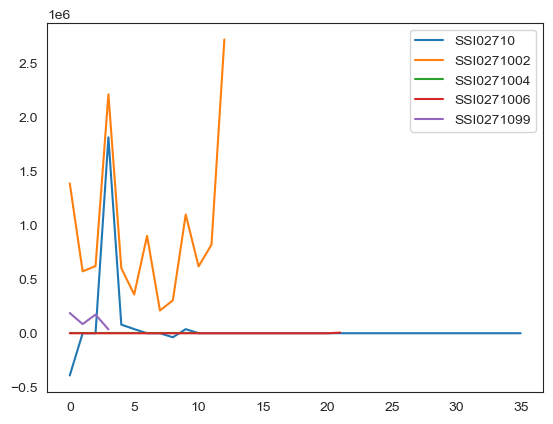

In [66]:
for subseg in list(series_dict.keys())[:5]:
    plt.plot(series_dict[subseg], label=subseg)

plt.legend()
plt.show()

In [ ]:
--

## 4. Data Preparation

### 4.1. Changing Datatypes

In [37]:
#Changing Datatypes
CRC['COUNT_CL'] = CRC['COUNT_CL'].round().astype('Int32')
CRC['COUNT_CP'] = CRC['COUNT_CP'].round().astype('Int32')
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].round().astype('Int32')
CRC['COUNT_HT'] = CRC['COUNT_HT'].round().astype('Int32')
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].round().astype('Int32')
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].round().astype('Int32')
CRC['COUNT_TOTAL'] = CRC['COUNT_TOTAL'].round().astype('Int32')

NameError: name 'CRC' is not defined

### 4.2. Handling Missing Values

### 4.3. Handling Outliers

### 4.4. Feature Engineering

### 4.5. Data Aggregation